In the name of God

# Q1: City Pictures Segmentation

In this note book we will be implementing the Fast SCNN segmentation model described in the q1-paper file (https://arxiv.org/pdf/1902.04502)

## 1.1 Describing the Proposed model

The proposed model (Fast-SCNN) consists of four main components shown in the image below:
* 1. Learning to Downsample
* 2. Global Feature Extractor
* 3. Feature Fusion
* 4. Classifier

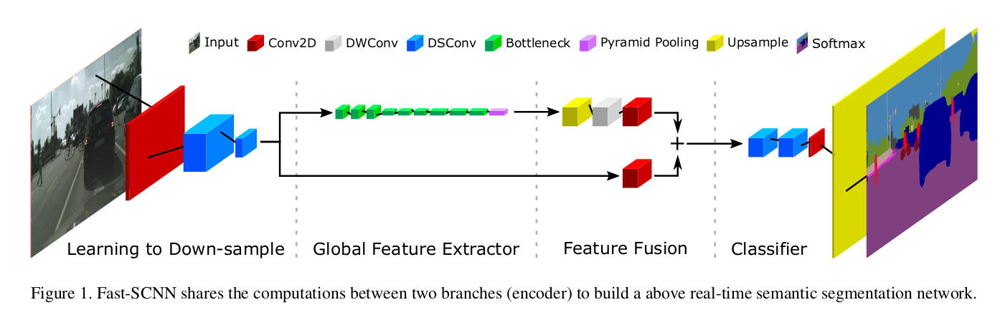

We'll go into more detail about each component in the following sections.


### 1.1.1 Learning to Down-Sample

This components aims to quickly reduce the spatial resolution and extract low-level features such as edges and textures, it consist of one 3x3 standard convolution with stride 2 (the red layer) and two 3x3 depthwise-separable convolutions with stride 2 _ What each of these terms mean will be discussed in greater detail in section 1.4_

After the image passes through this layer its resolution is reduced from 1024x2048 to 128x256, this reduced image will be later used in the two branch network in the later sections.

### 1.1.2 Global Feature Extractor

This section has been designed with the goal of capturing the broad and context rich features at a much lower resolution, it consists of a small stack of MobileNet-V2 inverted residual blocks (depthwise-separable convolutions and linear bottleneck) with a pyramid polling module at the end, which is use to upsample and concatenate the features maps.

### 1.1.3 Feature Fusion

In this section the model combines the high resolution detail with the low resolution features (the two branches). To do this the model upsamples the output of the global feature extractor, concatenates them with the corresponding feature maps of the other branch.

### 1.1.4 Classifier

As per any other segmentation network, the last layer is a classifier. In this model, it consists of a couple of depthwise-convolution layers to blend the feature maps, then using a normal convolution layer and a bilinear upsampling block, it converts the size back to the original resolution and assigns the pixel classes.

### 1.1.5 Similarities to Other Networks.

According to the authors themselves, the goal of the network was to use a similar structure to more complex encoder-decoder networks like U-Net but make them faster and achieve a structure like the faster two branch models. Instead of feeding the model the same image but with different resolutions, they utilized the first layers of the network to reduce the spatial size and extract some features (like U-net) and pass this information as the branch with the lower resolution image (or like a skip connection!)

## 1.2 Downloading and Showing the dataset

The dataset can be downloaded from this link: https://github.com/lih627/CamVid

The basic structure of the dataset is:

There are .txt files named vamcis_train, ... and these files contain the address to each of the corresponding images in that data and their gray-scale mask, we use this information to load our dataset and showing a few of the images

### 1.2.1 Loading the image paths

We load the image paths with the following code, to later be used for the model

In [1]:
from pathlib import Path

def load_split(txt_path, data_dir):
    lines = Path(txt_path).read_text().strip().splitlines()
    image_paths, gray_mask_paths, color_mask_paths = [], [], []

    for l in lines:
        img_path, gray_path = l.split()

        color_path = gray_path.replace("CamVidGray", "CamVidColor11")
        image_paths.append(data_dir + img_path)
        gray_mask_paths.append(data_dir + gray_path)
        color_mask_paths.append(data_dir + color_path)
        
    return image_paths, gray_mask_paths, color_mask_paths

data_dir = "./Data/CamVid-main/"
train_path = "./Data/CamVid-main/camvid_train.txt"
validation_path = "./Data/CamVid-main/camvid_val.txt"

(train_images, 
 train_gray_mask, 
 train_color_mask) = load_split(train_path, data_dir)

(validation_images,
 validation_gray_mask,
 validation_color_mask) = load_split(validation_path, data_dir)

print(f"Number of training images:   {len(train_images)}")
print(f"Number of validation images: {len(validation_images)}")

Number of training images:   367
Number of validation images: 101


In [2]:
from pathlib import Path

def load_data_paths(txt_path, data_dir):
    lines = Path(txt_path).read_text().strip().splitlines()

    image_paths = [data_dir + l.split()[0] for l in lines]
    mask_paths  = [data_dir + l.split()[1] for l in lines]
    
    return image_paths, mask_paths

data_dir = "./Data/CamVid-main/"
train_path = "./Data/CamVid-main/camvid_train.txt"
validation_path = "./Data/CamVid-main/camvid_val.txt" 

train_images, train_masks = load_data_paths(train_path, data_dir)
validation_images, val_masks = load_data_paths(validation_path, data_dir)



### 1.2.2 Showing a few random samples

The following code shows a few random samples of our training data

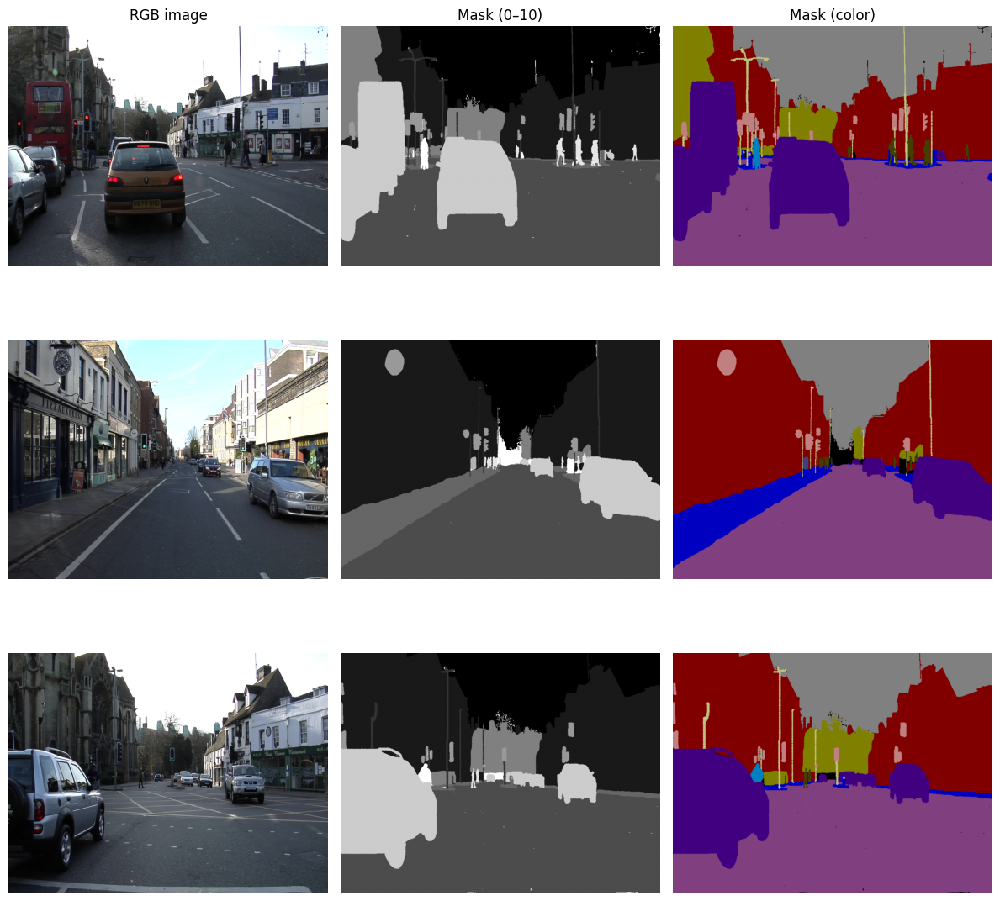

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import random

n_samples = 3
indexes = random.sample(range(len(train_images)), n_samples)

plt.figure(figsize=(12, 4 * n_samples))
for i, idx in enumerate(indexes):

    image = Image.open(train_images[idx])
    mask_gray = Image.open(train_gray_mask[idx])
    mask_color = Image.open(train_color_mask[idx])

    plt.subplot(n_samples, 3, 3*i + 1)
    plt.imshow(image)
    plt.axis("off")
    if i == 0: 
        plt.title("RGB image")

    plt.subplot(n_samples, 3, 3*i + 2)
    plt.imshow(mask_gray, cmap="gray", vmin=0, vmax=10)
    plt.axis("off")
    if i == 0: 
        plt.title("Mask (0–10)")

    plt.subplot(n_samples, 3, 3*i + 3)
    plt.imshow(mask_color)
    plt.axis("off")
    if i == 0: 
        plt.title("Mask (color)")

plt.tight_layout()
plt.show()

## 1.3 Optimizer, Metrics, and Cost Function

In this section we will discuss the metrics used, the optimizer and the cost function and implement them.

### 1.3.1 Metrics


#### 1.3.1.1 Dice Coefficient

Dice Coefficient is defined by twice the area of overlap, divided by the total number of pixels in both masks.

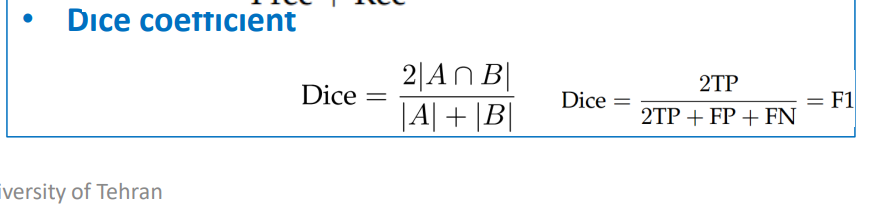

If we expand this in terms of TP, FP and FN we will reach the same equation as the F1-score, thus we can conclude the dice coefficient is basically the F1-score used for image segmentation.

The main advantage of using this metric is the fact that it emphasis both precision and recall and is useful in segmentation task where we often see class imbalances _ some objects like humans have much fewer pixels in the image compared to others like roads and this leads to the class imbalance, so if we used a metric like pixel accuracy, we would not be able to correctly measure our model.

#### 1.3.1.2 IoU score

Intersection over Union (IoU), also known as the Jaccard index, is another similar metric to Dice Coefficient as it's used for measuring the overlap in segmentation applications.

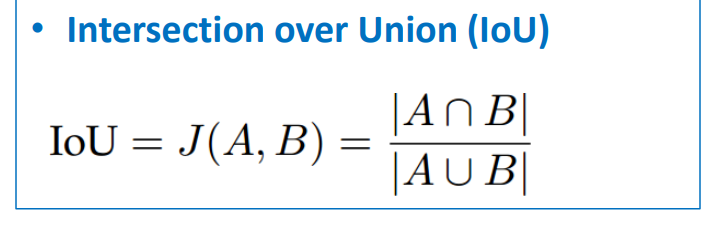

The main difference between IoU and Dice is that IoU penalizes miss-predictions higher than Dice as it measures what fraction of all pixels labeled either by you or the truth are correctly labeled by both.

It also helps with the class imbalance as it calculates a fraction between 0 and 1 and removes the effect of class size.

#### 1.3.2 Implementing the Metrics

The code below implements the metrics mentioned above

In [4]:
import tensorflow as tf

def dice_coefficient(y_label, y_predicted, class_cnt=11, epsilon=1e-6):
    dice_coefficients = []
    for i in range(class_cnt):
        y_label_i = tf.cast(y_label == i, tf.float32)
        y_predicted_i = tf.cast(y_predicted == i, tf.float32)

        intersection = tf.reduce_sum(y_label_i * y_predicted_i)
        union = tf.reduce_sum(y_label_i) + tf.reduce_sum(y_predicted_i)

        dice_class = (2. * intersection + epsilon) / (union + epsilon)
        dice_coefficients.append(dice_class)

    return tf.reduce_mean(dice_coefficients)

def iou(y_label, y_predicted, class_cnt=11, epsilon=1e-6):
    IoUs = []
    for i in range(class_cnt):
        y_label_i = tf.cast(y_label == i, tf.float32)
        y_predicted_i = tf.cast(y_predicted == i, tf.float32)

        intersection = tf.reduce_sum(y_label_i * y_predicted_i)
        union = tf.reduce_sum(y_label_i) + tf.reduce_sum(y_predicted_i) - intersection

        iou_class = (intersection + epsilon) / (union + epsilon)
        IoUs.append(iou_class)

    return tf.reduce_mean(IoUs)

2025-05-15 11:05:39.536247: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-15 11:05:39.545746: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747294539.559157    5989 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747294539.563275    5989 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747294539.573552    5989 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

#### 1.3.2 Loss Function


We'll use the combination of the dice loss and the loss implemented on the paper

In [5]:
# def dice_loss(y_true, y_pred):
#     return 1 - dice_coefficient(y_true, y_pred)

# combined_loss = tf.keras.losses.SparseCategoricalCrossentropy() + dice_loss

# model.compile(
#     optimizer=Adam(1e-3),
#     loss=combined_loss,
#     metrics=[dice_coefficient, iou_score, 'accuracy']
# )


## 1.4 Model Implementation

### 1.4.1 Model Structure

In this section we will go over the structure of the model as it was discussed in the paper.

The overall structure of the mode (its 4 main sections) were discussed in the previous parts, here we will be implementing each of them based on the description given in the paper. A summary of which can be found in Table 1:

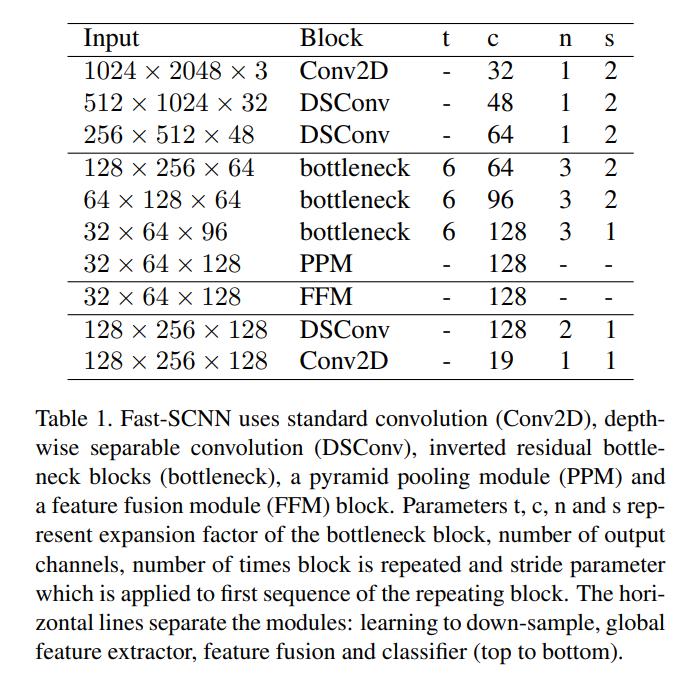

But before that, let's give a brief explanation about what each of these components do.

### 1.4.2 Depthwise Separable Convolution (DSC)

A typical convolution captures both spatial (depthwise) and cross-channel (pointwise) information of the filter, as you would usually use kernels with K x K x M size (K is the size of the kernel and M is the number of feature maps in the previous section), this however is quite computationally expensive.

Depthwise Separable Convolution breaks the normal convolution into two stages:
* __Depthwise Convolution__
    
    Where it applies a single K x K filter per input channel.

* __Pointwise Convolution__

    Where it applies 1x1 convolutions to mix all the channels together.

By doing this it reduces the computation (and memory) by and order of magnitude, while preserving the most of the capabilities of the normal convolution, resulting in faster and more lightweight models (which was the aim of this paper)

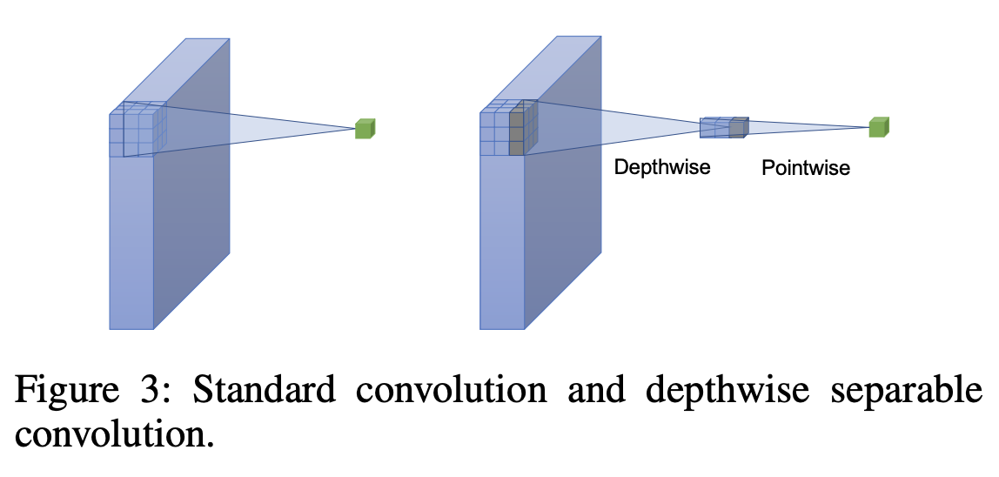

### 1.4.3 Depthwise Convolution

Depthwise Convolution is the first half of DSC. This layer focuses solely on learning the spatial features as it goes over only one feature map and attempts to extract information from it, the output of this layer can later be uses by a 1x1 (pointwise) convolution to combine these extracted information in a useful manner.

The main advantage of using such layers is the reduced computational/memory requirements and to increase speed, which is very important in realtime applications.

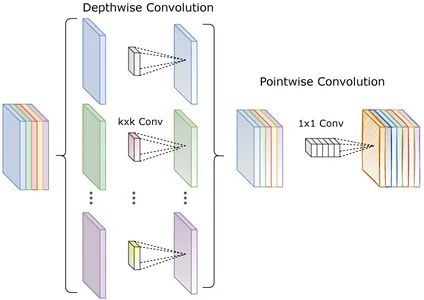


### 1.4.4 Inverted Residual Blocks

According to this article and the corresponding paper (https://paperswithcode.com/method/inverted-residual-block), Inverted Residual Blocks are the core building blocks introduces in MobileNetV2, they have been implemented in FastSCNN for global feature extraction as they offer a good balance between computational power and representational power.

The structure of these blocks (as shown in the image below) can be divided into three main sections:

* __Expansion (pointwise convolution)__
    
    Here a 1x1 convolution expands the number of feature maps by a factor of t (expansion factor), this is followed by batch normalization and ReLU6 (or ReLU)

* __Depthwise Convolution__

    A 3x3 depthwise convolution (usually with stride 1 or 2) is applied on the spatial channels to capture the structures. Again followed by batch normalization and ReLU6 (or ReLU)

* __Projection (pointwise convolution)__

    A final 1x1 convolution is then applied to reduce the number of projected channels (usually back to the original number of channels), this is again followed by batch normalization but this time without an activation function.

also when the number of input and output feature maps are kept the same, the block also includes a residual(skip) connection.

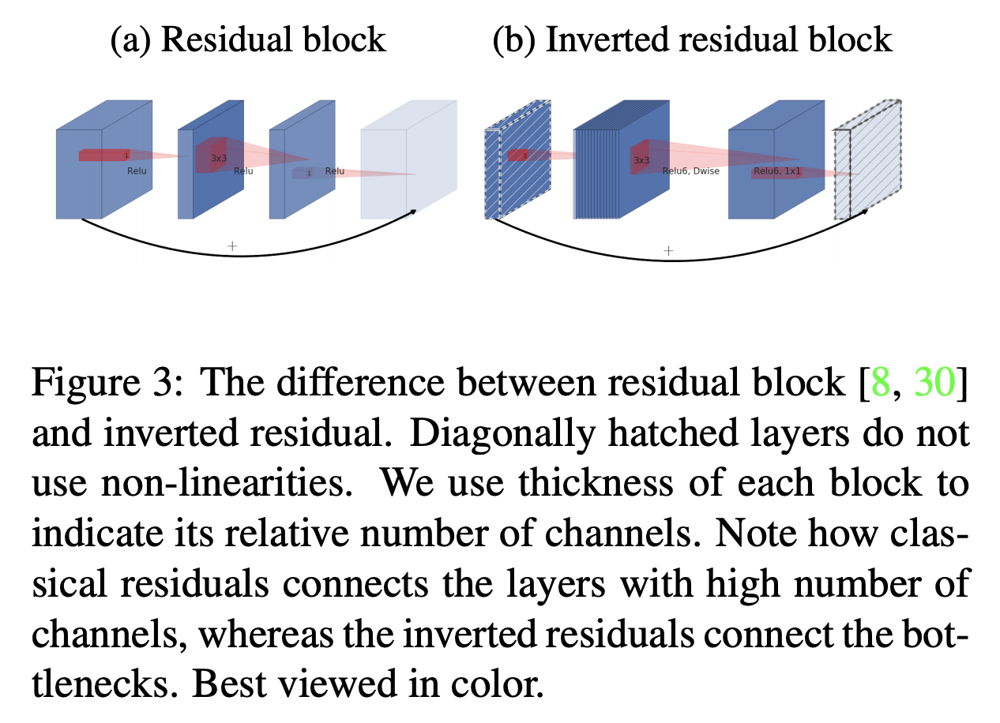

### 1.4.5 Pyramid Pooling Module

Pyramid Pooling Module (PPM, https://paperswithcode.com/method/pyramid-pooling-module) is designed to capture and integrate contextual information and different spatial scales, helping the model to understand both global and fine details, it was introduced in PSPNet and is uses in our model (Fast-SCNN) global feature extractor section to enrich the lower-resolution feature maps before fusion.

As shown in the image below, the module has 4 components:

* __Pooling at multiple grid scales__

    In this part spatial pooling with different output grid sizes (such as 1x1, 2x2, 3x3, 6x6, ...) is applied

* __1x1 Convolution and upsampling__

    After the pooling, each pooled map is passed through a 1x1 convolution (followed by batch normalization and ReLU) to reduce the number of feature maps.

* __Bilinear upsampling__

    Each of the feature maps are then upsampled back to the original spatial size.

* __Concatenation__

    Upsampled feature maps are then concatenated with the original maps, adding both global and fine context to them.

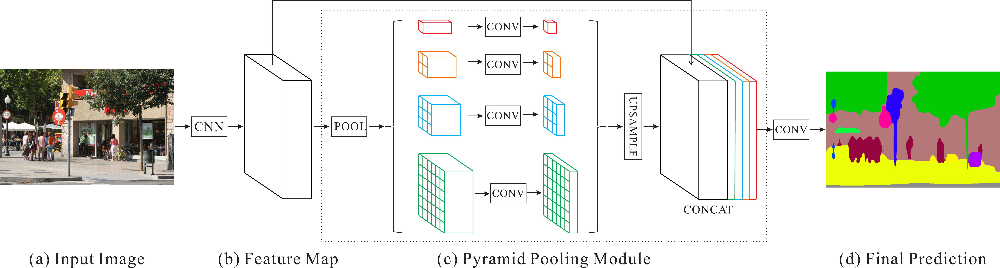

### 1.4.6 Model Implementation

In [6]:
from tensorflow.keras import layers
from tensorflow.keras import Input, Model

class FastSCNN:
    @staticmethod
    def depthwise_separable_conv(layer, filters, kernel_size=3, strides=1, padding='same'):
        
        layer = layers.DepthwiseConv2D(kernel_size=kernel_size, strides=strides, padding=padding, use_bias=False)(layer)
        layer = layers.BatchNormalization(epsilon=1e-5)(layer)
        layer = layers.ReLU()(layer)
        layer = tf.keras.layers.Lambda(lambda x: tf.clip_by_value(x, -1e3, 1e3))(layer)
        
        layer = layers.Conv2D(filters, kernel_size=1, strides=1, padding='same', use_bias=False)(layer)
        layer = layers.BatchNormalization(epsilon=1e-5)(layer)
        layer = layers.ReLU()(layer)
        layer = tf.keras.layers.Lambda(lambda x: tf.clip_by_value(x, -1e3, 1e3))(layer)
        
        return layer

    @staticmethod
    def inverted_residual_block(input_layer, filters, expansion_factor=6, stride=1):
        input_channels = input_layer.shape[-1]
        expanded_channels = input_channels * expansion_factor

        layer = layers.Conv2D(expanded_channels, kernel_size=1, strides=1, padding='same', use_bias=False)(input_layer)
        layer = layers.BatchNormalization(epsilon=1e-5)(layer)
        layer = layers.ReLU()(layer)
        layer = tf.keras.layers.Lambda(lambda x: tf.clip_by_value(x, -1e3, 1e3))(layer)

        layer = layers.DepthwiseConv2D(kernel_size=3, strides=stride, padding='same', use_bias=False)(layer)
        layer = layers.BatchNormalization(epsilon=1e-5)(layer)
        layer = layers.ReLU()(layer)
        layer = tf.keras.layers.Lambda(lambda x: tf.clip_by_value(x, -1e3, 1e3))(layer)

        layer = layers.Conv2D(filters, kernel_size=1, strides=1, padding='same', use_bias=False)(layer)
        layer = layers.BatchNormalization(epsilon=1e-5)(layer)

        # residula connection for when the input and output channels are the same
        if stride == 1 and input_channels == filters:
            layer = layers.Add()([layer, input_layer])

        return layer

    @staticmethod
    def pyramid_pooling_module(layer, pool_sizes=(1, 2, 3, 6), reduction_dim=None):
        H, W, C = layer.shape[1], layer.shape[2], layer.shape[3]
        if reduction_dim is None:
            reduction_dim = C // len(pool_sizes)
        
        pooled_outputs = [layer]
        
        for i, p in enumerate(pool_sizes):
            pooled = layers.AveragePooling2D(pool_size=(H // p, W // p),
                                        strides=(H // p, W // p),
                                        padding='valid')(layer)
            conved = layers.Conv2D(reduction_dim, kernel_size=1, strides=1, padding='same', use_bias=False)(pooled)
            conved = layers.BatchNormalization(epsilon=1e-5)(conved)
            conved = layers.ReLU()(conved)
            layer = tf.keras.layers.Lambda(lambda x: tf.clip_by_value(x, -1e3, 1e3))(layer)
            upsampled = layers.UpSampling2D(size=(H // tf.shape(conved)[1], W // tf.shape(conved)[2]), interpolation='bilinear')(conved)
            pooled_outputs.append(upsampled)
        
        out = layers.Concatenate()(pooled_outputs)
        return out
    
    @staticmethod 
    def global_pooling(layer, reduction_dim=128):
        layer = layers.GlobalAveragePooling2D()(layer)
        layer = layers.Reshape((1, 1, layer.shape[-1]))(layer)
        layer = layers.Conv2D(reduction_dim, 1, padding='same')(layer)
        layer = layers.ReLU()(layer)
        layer = tf.keras.layers.Lambda(lambda x: tf.clip_by_value(x, -1e3, 1e3))(layer)
        layer = layers.UpSampling2D(size=(32, 32), interpolation='bilinear')(layer)

        return layer

    @staticmethod
    def feature_fusion(high_res, low_res, filters):
        low_branch = layers.Conv2D(128, 1, padding='same', use_bias=False)(low_res)
        low_branch = layers.BatchNormalization(epsilon=1e-5)(low_branch)

        # Dynamically resize HIGH to match LOW
        def resize_high(tensors):
            high, low = tensors
            low_shape = tf.shape(low)[1:3]
            return tf.image.resize(high, low_shape, method='bilinear')

        high_branch = layers.Lambda(resize_high)([high_res, low_branch])

        high_branch = layers.DepthwiseConv2D(kernel_size=3, dilation_rate=2, padding='same', use_bias=False)(high_branch)
        high_branch = layers.BatchNormalization(epsilon=1e-5)(high_branch)
        high_branch = layers.ReLU()(high_branch)
        high_branch = tf.keras.layers.Lambda(lambda x: tf.clip_by_value(x, -1e3, 1e3))(high_branch)

        high_branch = layers.Conv2D(filters, kernel_size=1, strides=1, padding='same', use_bias=False)(high_branch)
        high_branch = layers.BatchNormalization(epsilon=1e-5)(high_branch)
        high_branch = layers.ReLU()(high_branch)
        high_branch = tf.keras.layers.Lambda(lambda x: tf.clip_by_value(x, -1e3, 1e3))(high_branch)
        
        fused = layers.Add()([low_branch, high_branch])
        fused = layers.ReLU()(fused)
        fused = tf.keras.layers.Lambda(lambda x: tf.clip_by_value(x, -1e3, 1e3))(fused)
        
        return fused

    @staticmethod
    def learning_to_downsample(inputs):
        layer = layers.Conv2D(32, kernel_size=3, strides=2, padding='same', use_bias=False)(inputs)
        layer = layers.BatchNormalization(epsilon=1e-5)(layer)
        layer = layers.ReLU()(layer)
        layer = tf.keras.layers.Lambda(lambda x: tf.clip_by_value(x, -1e3, 1e3))(layer)

        layer = FastSCNN.depthwise_separable_conv(layer, filters=48, kernel_size=3, strides=2)

        layer = FastSCNN.depthwise_separable_conv(layer, filters=64, kernel_size=3, strides=2)

        return layer

    @staticmethod
    def global_feature_extractor(layer):
        for _ in range(3):
            layer = FastSCNN.inverted_residual_block(layer, filters=64,  expansion_factor=6, stride=2)

        for _ in range(3):
            layer = FastSCNN.inverted_residual_block(layer, filters=96,  expansion_factor=6, stride=2)

        for _ in range(3):
            layer = FastSCNN.inverted_residual_block(layer, filters=128, expansion_factor=6, stride=1)

        layer = FastSCNN.global_pooling(layer)
        return layer
    
    @staticmethod
    def classifier(head, num_classes, upsample_size):
        layer = FastSCNN.depthwise_separable_conv(head, filters=128, kernel_size=3, strides=1)
        layer = FastSCNN.depthwise_separable_conv(layer, filters=128, kernel_size=3, strides=1)

        layer = layers.Conv2D(num_classes, kernel_size=1, strides=1, padding='same', use_bias=False)(layer)

        # layer = layers.Lambda(lambda t: tf.debugging.check_numerics(t, "Logits contain NaN or Inf"))(layer)

        layer = layers.Lambda(lambda t: tf.image.resize(t, size=upsample_size, method='bilinear'))(layer)

        layer = layers.Softmax(name='classifier_softmax')(layer)

        return layer

    @staticmethod
    def build_fast_scnn():
        inp = Input(shape=(720, 960, 3))

        downsample = FastSCNN.learning_to_downsample(inp)

        feature_extractor = FastSCNN.global_feature_extractor(downsample)

        fusion = FastSCNN.feature_fusion(high_res=downsample, low_res=feature_extractor, filters=128)

        logits = FastSCNN.classifier(fusion, num_classes=11, upsample_size=(720, 960))

        model = Model(inputs=inp, outputs=logits)

        return model

model = FastSCNN.build_fast_scnn()
model.summary()

I0000 00:00:1747294540.880654    5989 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6168 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 720, 960,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 360, 480,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 360, 480,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 360, 480,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 360, 480,  │          0 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 180, 240,  │        288 │ lambda[0][0]      │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 240,  │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 180, 240,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 180, 240,  │          0 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 180, 240,  │      1,536 │ lambda_1[0][0]    │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 240,  │        192 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 180, 240,  │          0 │ batch_normalizat… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 180, 240,  │          0 │ re_lu_2[0][0]     │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 90, 120,   │        432 │ lambda_2[0][0]    │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 90, 120,   │        192 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 90, 120,   │          0 │ batch_normalizat… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 90, 120,   │          0 │ re_lu_3[0][0]   

 Total params: 1,125,936 (4.30 MB)

 Trainable params: 1,102,896 (4.21 MB)

 Non-trainable params: 23,040 (90.00 KB)

## 1.5 Training the Model

### 1.5.1 Preprocessing

Before training the model, we prepare the previously loaded data and convert it into suitable formats

In [7]:
import tensorflow as tf

IMG_HEIGHT = 720
IMG_WIDTH  = 960
NUM_CLASSES = 11

def decode_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0
    return image

def decode_mask(path):
    mask = tf.io.read_file(path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_HEIGHT, IMG_WIDTH], method='nearest')
    mask = tf.cast(mask, tf.uint8)
    return mask

def preprocess(image_path, mask_path):
    image  = decode_image(image_path)
    mask = decode_mask(mask_path)
    tf.debugging.assert_all_finite(image, "Image contains NaN or Inf")
    tf.debugging.assert_all_finite(tf.cast(mask, tf.float32), "Mask contains NaN or Inf")
    return image, mask

def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image  = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)
    return image, mask


### 1.5.2 Building the dataset

Here we will build the data set (in a way suitable with the model)

In [8]:
def make_dataset(image_paths, mask_paths, batch_size, training=True):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    if training:
        dataset = dataset.shuffle(buffer_size=500, seed=24)
    dataset = dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

BATCH_SIZE = 4

train_dataset = make_dataset(train_images, train_masks, BATCH_SIZE, training=True)
val_dataset = make_dataset(validation_images, val_masks, BATCH_SIZE, training=False)


### 1.5.3 Compiling the Model


Here we will compile the model and use our costume loss (which was commented in the previous section)

In [ ]:
# def dice_loss(y_label, y_prediction, smooth=1e-6):
#     y_label_flattened = K.flatten(tf.one_hot(tf.squeeze(y_label, -1), NUM_CLASSES))
#     y_prediction_flattened = K.flatten(y_prediction)
#     intersection = K.sum(y_label_flattened * y_prediction_flattened)
#     return 1 - (2. * intersection + smooth) / (
#         K.sum(y_label_flattened) + K.sum(y_prediction_flattened) + smooth
#     )

# def combined_loss(y_true, y_pred):
#     ce = tf.keras.losses.SparseCategoricalCrossentropy()(y_true, y_pred)
#     dl = dice_loss(y_true, y_pred)
#     return ce + dl


In [ ]:
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K


optimizer = Adam(learning_rate=1e-5, clipnorm=0.1)
model = FastSCNN.build_fast_scnn()
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy', dice_coefficient, iou],
    run_eagerly=True
)


### 1.5.4 Finally, Training the Model!

In [ ]:
# from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, TensorBoard

# callbacks = [
#     ModelCheckpoint('fast_scnn_camvid.h5', monitor='val_iou', 
#                     save_best_only=True, mode='max'),
#     ReduceLROnPlateau(monitor='val_iou', factor=0.5, 
#                       patience=5, mode='max', min_lr=1e-6),
#     EarlyStopping(monitor='val_iou', patience=10, mode='max', restore_best_weights=True),
#     TensorBoard(log_dir='logs/fast_scnn')
# ]


In [ ]:

EPOCHS = 20

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    verbose=2
)

Epoch 1/30
92/92 - 55s - 596ms/step - accuracy: 0.1688 - dice_coefficient: 0.0138 - iou: 0.0138 - loss: nan - val_accuracy: 0.0920 - val_dice_coefficient: 2.9454e-11 - val_iou: 2.9454e-11 - val_loss: nan
Epoch 2/30
92/92 - 55s - 603ms/step - accuracy: 0.1688 - dice_coefficient: 0.0128 - iou: 0.0128 - loss: nan - val_accuracy: 0.0920 - val_dice_coefficient: 2.9454e-11 - val_iou: 2.9454e-11 - val_loss: nan
Epoch 3/30
92/92 - 57s - 615ms/step - accuracy: 0.1688 - dice_coefficient: 0.0099 - iou: 0.0099 - loss: nan - val_accuracy: 0.0920 - val_dice_coefficient: 2.9454e-11 - val_iou: 2.9454e-11 - val_loss: nan
Epoch 4/30


KeyboardInterrupt: 

### 1.6 Showing the Results

As we can see, despite the average accuracy of the model (0.65) the low iou-score of the model resulted in vary pool visual segmentation, perhaps with more time and tinkering and better parameter fine tuning we would be able to improve the model.

Below we can see the results of the model on 10 images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


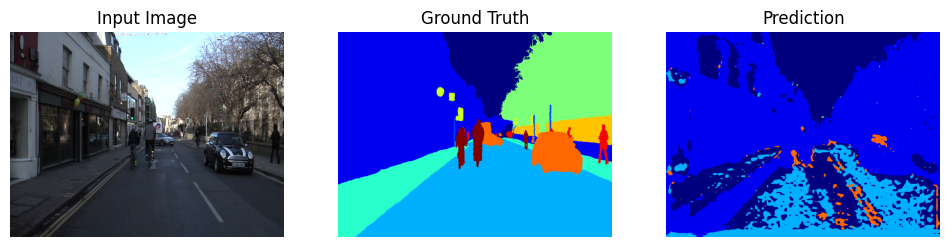

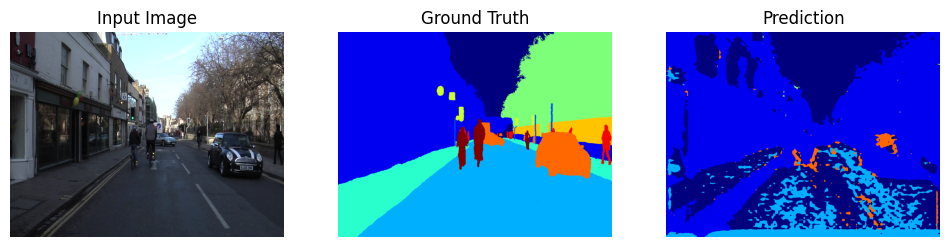

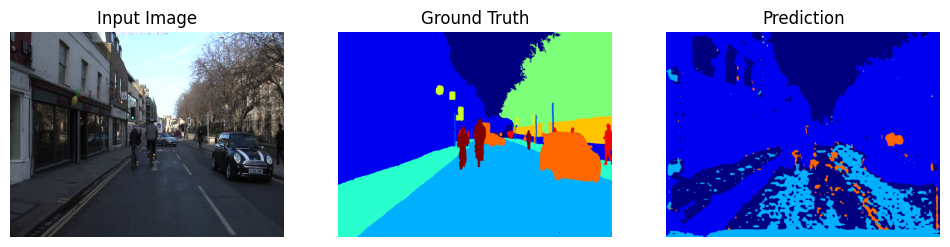

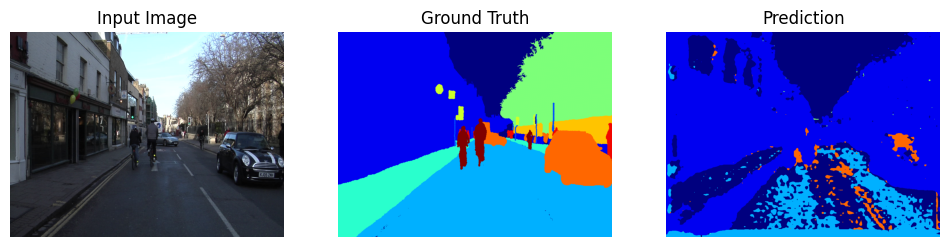

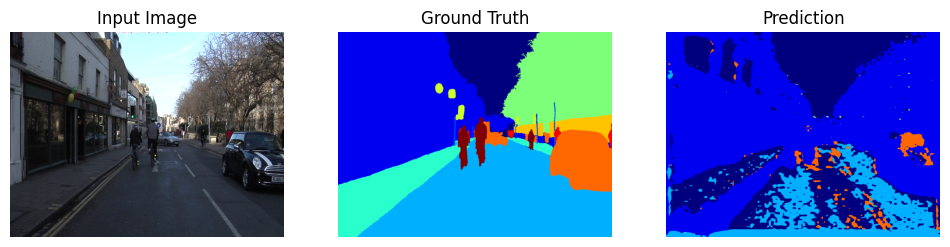

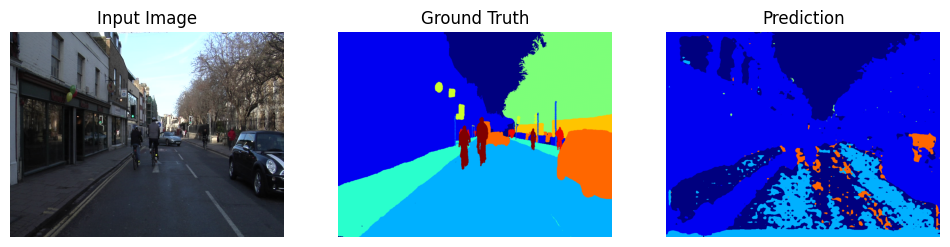

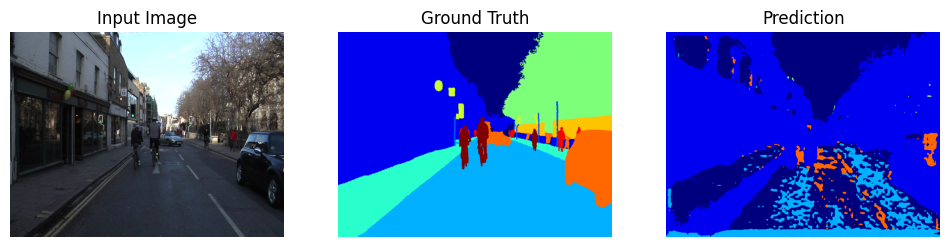

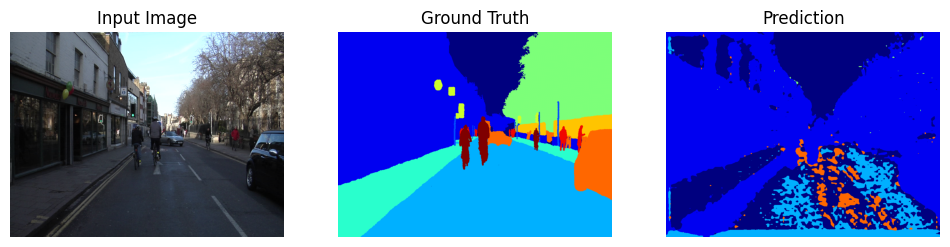

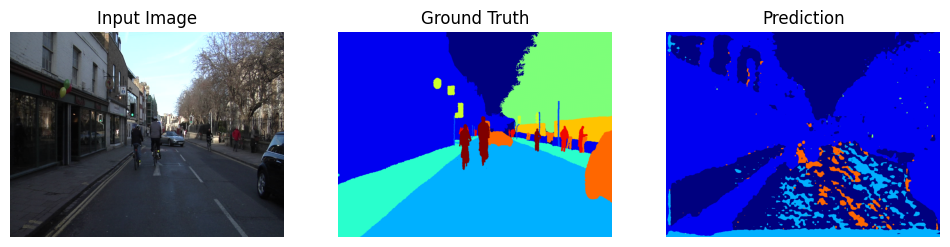

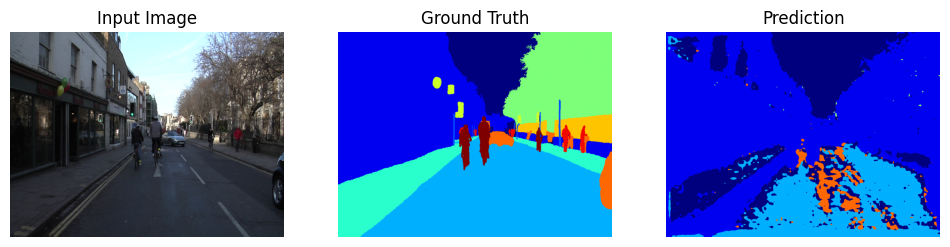

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

imgs, masks = next(iter(val_dataset))

preds = model.predict(imgs)

NUM_CLASSES = 11
for i in range(min(10, imgs.shape[0])):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    axes[0].imshow(imgs[i].numpy())
    axes[0].set_title('Input Image')
    axes[0].axis('off')
    
    axes[1].imshow(tf.squeeze(masks[i]).numpy(), cmap='jet', vmin=0, vmax=NUM_CLASSES-1)
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')
    
    pred_mask = tf.argmax(preds[i], axis=-1)
    axes[2].imshow(pred_mask.numpy(), cmap='jet', vmin=0, vmax=NUM_CLASSES-1)
    axes[2].set_title('Prediction')
    axes[2].axis('off')
    
    plt.show()
